### **We filter out values <0.5km2 and calculate the area**

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [94]:
# Filtering and Noise Reduction
vector_path = '../data/final/2025_pred_masked.gpkg'
gdf = gpd.read_file(vector_path)
print("origin_CRS:", gdf.crs)

gdf_proj = gdf.to_crs("EPSG:32647")
gdf_proj['area_km2'] = gdf_proj.area / 1_000_000

top20 = gdf_proj.nlargest(20, 'area_km2')

print("The top 20 elements by area:")
print(top20[['DN', 'area_km2']].to_string(index=True))

origin_CRS: EPSG:4326
The top 20 elements by area:
     DN     area_km2
390   1  4575.862504
295   1    49.404706
393   1     6.173634
361   1     1.757241
208   1     0.597610
176   1     0.557599
397   1     0.412739
340   1     0.302986
190   1     0.234103
344   1     0.228942
323   1     0.214159
139   1     0.199791
277   1     0.148896
358   1     0.136058
262   1     0.123986
188   1     0.116574
330   1     0.115871
379   1     0.106121
199   1     0.097440
200   1     0.096169


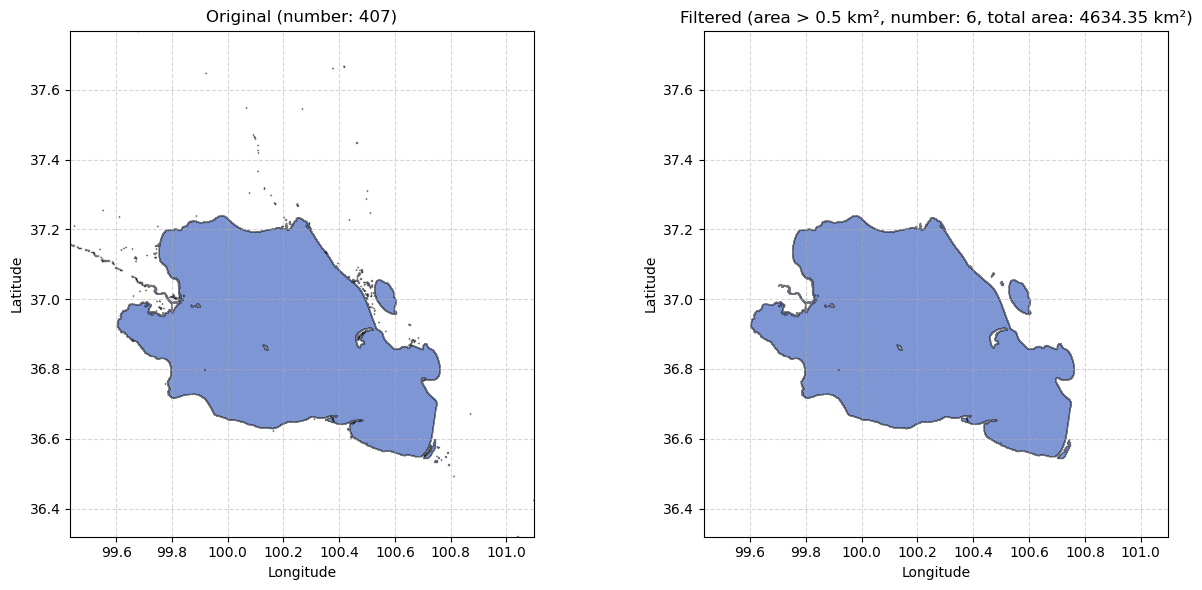

In [95]:
#Filter out areas smaller than 0.5 square kilometers
gdf_proj = gdf.to_crs("EPSG:32647")
gdf_proj['area_km2'] = gdf_proj.area / 1_000_000   
COBALT_BLUE = "#002EAB"

threshold = 0.5
gdf_main = gdf_proj[gdf_proj['area_km2'] > threshold].copy()
gdf_main_geo = gdf_main.to_crs("EPSG:4326")  # 转回地理坐标系用于绘图

# 计算原始数据的地理范围（用于统一坐标轴）
bounds = gdf.total_bounds  # [minx, miny, maxx, maxy]


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))


gdf.plot(ax=ax1, color=COBALT_BLUE, edgecolor='black', alpha=0.5)
ax1.set_title(f"Original (number: {len(gdf)})")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.grid(True, linestyle='--', alpha=0.5)

ax1.set_xlim(bounds[0], bounds[2])
ax1.set_ylim(bounds[1], bounds[3])


if len(gdf_main) > 0:
    gdf_main_geo.plot(ax=ax2, color=COBALT_BLUE, edgecolor='black', alpha=0.5)
    total_main_km2 = gdf_main['area_km2'].sum()
    ax2.set_title(f"Filtered (area > {threshold} km², number: {len(gdf_main)}, total area: {total_main_km2:.2f} km²)")
else:
    ax2.text(0.5, 0.5, f'No features > {threshold} km²', ha='center', va='center', transform=ax2.transAxes)
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.grid(True, linestyle='--', alpha=0.5)

ax2.set_xlim(bounds[0], bounds[2])
ax2.set_ylim(bounds[1], bounds[3])

plt.tight_layout()
plt.show()